# Reaction Basics

In [1]:
%pip install pandas rdkit mols2grid


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 1. Introduction
In this notebook we demonstrate a simple two-component library enumeration. We begin by sketching the reaction using the sketcher on the [Marvin JS Demo page](https://marvinjs-demo.chemaxon.com/latest/demo.html).  Once we've sketched the reaction, we will export the reaction as a **Reaction SMARTS** that can be processed by the RDKit. We will then look at how we can use that reaction SMARTS to enumerate a chemical library. A reaction SMARTS is similar to the SMARTS we saw in the previous notebook, with a couple of additions.  The reaction smarts consists of two parts separated by a reaction arrow, written as **">>"**. The part of the reaction SMARTS to the left of the reaction arrow represents the reactants and the part to the right represents the products.  The other difference from a typical SMARTS is the atom map numbers that follow the **":"** in the reaction SMARTS (shown in red in the figure below).  These specify the correspondence between reactant atoms and product atoms. Atom 1 in the reactants maps to atom 1 in the products, and so on.  By specifying reactions this way, we can transform a set of reactants into a reaction product. It's important to remember that reaction processing in the RDKit proceeds in two steps. 
1. The reaction smarts for the reactants are mapped to the supplied reactants. This enables the RDKit reaction object to determine which reactant atoms will be transformed to product atoms. As such, it is important to specify the number of hydrogens attached to heteroatoms in the reactants.  We'll go into this more below.  Notice the hydrogen counts on the oxygen and the nitrogen in the reactants (highlighted in yellow).  We will also discuss this more in subsequent sections. 
2. The atom mappings in the product are used to transform the reactants into products. 

<img src="https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/reaction/images/amiderxn_000.png" alt="Drawing" style="width: 800px;"/>

### 2. Set Up the Reaction
In this section, we'll sketch a reaction and export it as a Reaction SMARTS that can be used by the RDKit. We begin by using the [Marvin JS Demo page](https://marvinjs-demo.chemaxon.com/latest/demo.html) to sketch an amide reaction. Note that it's not necessary to put a "+" between the reactants. 

In [2]:
# need some time to get the gist. Some troubles wiht understanding how to use this app

In [3]:
# lets assume we did it, and extracted smarts file of the reaction

Allright, we've finished the preliminaries. Let's write some code! We begin by importing the necessary Python libraries.

In [22]:
from itertools import product

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import MolsToGridImage

import pandas as pd
import mols2grid

In [23]:
rxn_smarts = "[#7H2:7]-[#6:9].[#8H]-[#6:1](-[#6:2])=[O:3]>>[#6:9]-[#7:7]-[#6:1](-[#6:2])=[O:3]"

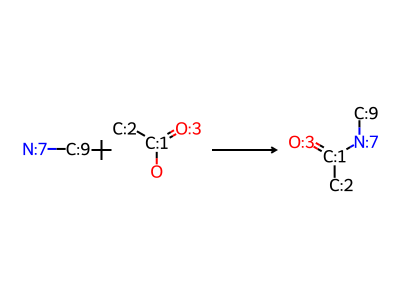

In [24]:
rxn_mol = AllChem.ReactionFromSmarts(rxn_smarts)
rxn_mol

## 3. Test the reaction

Let's run a quick example to make sure our reaction works as expected. We'll perform a simple reaction where we combine acetic acid with methylamine. Note that the reactants must be in the same order specified in the reaction SMARTS. If the reactants are not in the same order, you won't get a a reaction product.

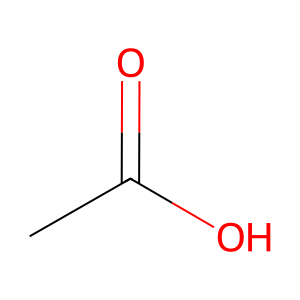

In [25]:
acid_mol = Chem.MolFromSmiles("CC(=O)O")
acid_mol

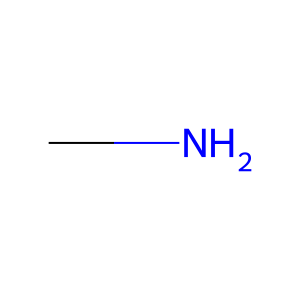

In [26]:
amine_mol = Chem.MolFromSmiles("CN")
amine_mol

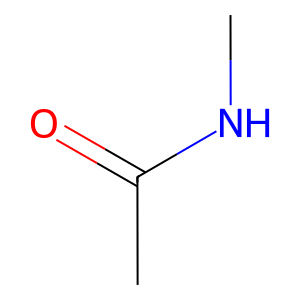

In [33]:
prods = rxn_mol.RunReactants([amine_mol, acid_mol])
prods[0][0]

### 5. Enumerate a SMALL library
Now we'll enumerate a library with 10 amines and 10 carboxylic acids.  We begin by reading the reagents from a file.

In [38]:
import ssl, certifi, urllib.request

def read_csv(url):
    ctx = ssl.create_default_context(cafile=certifi.where())
    with urllib.request.urlopen(url, context=ctx) as resp:
        df = pd.read_csv(resp)
        return df

In [41]:
df = read_csv("https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/reaction/data/amide_reagents.csv")
df

,SMILES,Name,Type
0,N=C(N)NC[C@@H](N)C(=O)O,1576365,carboxylic_acid
1,CN(C)C[C@@H](N)C(=O)O,35024242,carboxylic_acid
2,Nc1nnn(CC(=O)O)n1,4294607,carboxylic_acid
3,COC(=O)[C@@H](O)CC(=O)O,14585673,carboxylic_acid
4,N=C(N)NC[C@H](N)C(=O)O,2384694,carboxylic_acid
5,N[C@H](CO)C(=O)O,895342,carboxylic_acid
6,NCC[C@H](N)C(=O)O,52986906,carboxylic_acid
7,C[C@@H](O)[C@H](N)C(=O)O,895103,carboxylic_acid
8,NC(=O)[C@H](N)CCC(=O)O,2560808,carboxylic_acid
9,NCC(=O)NCCC(=O)O,1637970,carboxylic_acid


Add a column to the dataframe with RDKit molecules.

In [42]:
df['mol'] = df.SMILES.apply(Chem.MolFromSmiles)

In [43]:
df

,SMILES,Name,Type,mol
0,N=C(N)NC[C@@H](N)C(=O)O,1576365,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08740>
1,CN(C)C[C@@H](N)C(=O)O,35024242,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d086d0>
2,Nc1nnn(CC(=O)O)n1,4294607,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d087b0>
3,COC(=O)[C@@H](O)CC(=O)O,14585673,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08820>
4,N=C(N)NC[C@H](N)C(=O)O,2384694,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08900>
5,N[C@H](CO)C(=O)O,895342,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08890>
6,NCC[C@H](N)C(=O)O,52986906,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d089e0>
7,C[C@@H](O)[C@H](N)C(=O)O,895103,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08970>
8,NC(=O)[C@H](N)CCC(=O)O,2560808,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08a50>
9,NCC(=O)NCCC(=O)O,1637970,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08ac0>


Split the acids and amines into separate dataframes.

In [56]:
acid_df = df.query("Type == 'carboxylic_acid'").copy()
amine_df = df.query("Type == 'primary_amine'").copy()

In [57]:
acid_df

,SMILES,Name,Type,mol
0,N=C(N)NC[C@@H](N)C(=O)O,1576365,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08740>
1,CN(C)C[C@@H](N)C(=O)O,35024242,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d086d0>
2,Nc1nnn(CC(=O)O)n1,4294607,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d087b0>
3,COC(=O)[C@@H](O)CC(=O)O,14585673,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08820>
4,N=C(N)NC[C@H](N)C(=O)O,2384694,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08900>
5,N[C@H](CO)C(=O)O,895342,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08890>
6,NCC[C@H](N)C(=O)O,52986906,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d089e0>
7,C[C@@H](O)[C@H](N)C(=O)O,895103,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08970>
8,NC(=O)[C@H](N)CCC(=O)O,2560808,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08a50>
9,NCC(=O)NCCC(=O)O,1637970,carboxylic_acid,<rdkit.Chem.rdchem.Mol object at 0x118d08ac0>


In [49]:
mols2grid.display(acid_df,subset=["img","Name"])

In [50]:
mols2grid.display(amine_df,subset=["img","Name"])

Make lists of acids and amines to use for the enumeration.

In [61]:
# every rows becomes an array
# in the end -> an array of arrays with [mol_object, Name]
acid_list = acid_df[['mol','Name']].values
amine_list = amine_df[['mol','Name']].values

In [58]:
acid_list

array([[<rdkit.Chem.rdchem.Mol object at 0x118d08740>, 1576365],
       [<rdkit.Chem.rdchem.Mol object at 0x118d086d0>, 35024242],
       [<rdkit.Chem.rdchem.Mol object at 0x118d087b0>, 4294607],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08820>, 14585673],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08900>, 2384694],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08890>, 895342],
       [<rdkit.Chem.rdchem.Mol object at 0x118d089e0>, 52986906],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08970>, 895103],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08a50>, 2560808],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08ac0>, 1637970]],
      dtype=object)

In [59]:
amine_list

array([[<rdkit.Chem.rdchem.Mol object at 0x118d08b30>, 19844301],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08ba0>, 203414649],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08c10>, 2263862],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08c80>, 20436848],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08cf0>, 33691246],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08dd0>, 12957834],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08d60>, 35024242],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08eb0>, 4294607],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08e40>, 8657],
       [<rdkit.Chem.rdchem.Mol object at 0x118d08f20>, 895342]],
      dtype=object)

In [52]:
def enumerate_library(rxn_mol, reagent_lol):
    prod_list = []
    # itertools.product generates all combinations of reactants
    for reagents in product(*reagent_lol):
        mol_list = [x[0] for x in reagents]
        name_list = [str(x[1]) for x in reagents]
        name = "_".join(name_list)
        prod = rxn_mol.RunReactants(mol_list)
        if prod is not None and len(prod):
            product_mol = prod[0][0]
            Chem.SanitizeMol(product_mol)
            prod_list.append([Chem.MolToSmiles(product_mol), name])
    return prod_list

Enumerate the library

Put the products into a dataframe

# `enumerate_library` — how combinatorial enumeration works

Takes one reaction and a set of reagent lists, runs the reaction on **every combination** of reagents, and returns all the products. This is how a combinatorial chemical library is built.

---

## The function

```python
def enumerate_library(rxn_mol, reagent_lol):
    prod_list = []
    for reagents in product(*reagent_lol):          # every reagent combination
        mol_list  = [x[0] for x in reagents]        # pull out the molecules
        name_list = [str(x[1]) for x in reagents]   # pull out the names
        name = "_".join(name_list)                  # e.g. "amine1_acid2"
        prod = rxn_mol.RunReactants(mol_list)       # run the reaction
        if prod is not None and len(prod):          # did it work?
            product_mol = prod[0][0]                # take the product
            Chem.SanitizeMol(product_mol)           # fix H count, aromaticity, valences
            prod_list.append([Chem.MolToSmiles(product_mol), name])
    return prod_list
```

---

## Where the data comes from

```python
acid_list  = acid_df[['mol','Name']].values
amine_list = amine_df[['mol','Name']].values
```

Read inside-out:

| Piece | What it does | Result |
|---|---|---|
| `acid_df` | a table (DataFrame) with columns incl. `mol` and `Name` | full table |
| `[['mol','Name']]` | select **only** those two columns, in that order | 2-column table |
| `.values` | drop headers, turn rows into a plain array | **list of pairs** |

So each `*_list` becomes a **list of `[molecule, name]` pairs**:

```python
acid_list = [ [molX1, "acid1"],
              [molX2, "acid2"] ]
```

And the call wraps both into a **list of lists** (`reagent_lol`):

```python
enumerate_library(rxn_mol, [amine_list, acid_list])
#                          └──────── reagent_lol ────────┘
```

---

## The two tricky pieces

### `product` — all combinations

`itertools.product` takes one item from each list and yields **every possible pairing** (like a multiplication table for lists).

```python
from itertools import product
product(["red","blue"], ["S","M","L"])
# → ('red','S') ('red','M') ('red','L') ('blue','S') ('blue','M') ('blue','L')
#   2 × 3 = 6 combinations
```

For chemistry: every amine paired with every acid.

### `*` — unpack the outer list

`product` wants the lists as **separate arguments**, but ours are wrapped inside one list. `*` unpacks them:

```python
reagent_lol = [amine_list, acid_list]

product(reagent_lol)    # one argument — treats the whole thing as a single list
product(*reagent_lol)   # = product(amine_list, acid_list)
```

> **Analogy:** `product(bag)` hands over the whole bag; `product(*bag)` tips it out so each item goes in separately.

Written with `*` so the function works with **any number** of components — 2, 3, or 5 reagent lists — not just two.

---

## `x[0]` vs `x[1]` — unzipping the pairs

Inside the loop, each `x` is one `[mol, name]` pair:

| Expression | Meaning |
|---|---|
| `x[0]` | the **molecule** |
| `x[1]` | the **name** |

```python
mol_list  = [x[0] for x in reagents]   # molecules → go into the reaction
name_list = [x[1] for x in reagents]   # names → build the product name
```

These two lines split the pairs back into two separate things.

---

## Line-by-line, one iteration

Given `reagents = ( [molA,"amineA"], [molX,"acidX"] )`:

| Line | Value produced |
|---|---|
| `mol_list = [x[0] for x in reagents]` | `[molA, molX]` |
| `name_list = [x[1] for x in reagents]` | `["amineA", "acidX"]` |
| `name = "_".join(name_list)` | `"amineA_acidX"` |
| `prod = rxn_mol.RunReactants(mol_list)` | raw reaction output |
| `if prod is not None and len(prod)` | did the reaction fire? |
| `product_mol = prod[0][0]` | the product molecule |
| `Chem.SanitizeMol(product_mol)` | recompute H / aromaticity / valences |
| `prod_list.append([...])` | `["<amide smiles>", "amineA_acidX"]` |

---

## `SanitizeMol` — what it "cleans"

Not impurities — it brings the molecule to a **chemically consistent state** after the reaction rewired atoms and bonds. `RunReactants` doesn't recompute these automatically:

- **implicit H counts** (valences changed — N lost an H)
- **aromaticity** (re-perceive which rings are aromatic)
- **valences** (flag any impossible atom, e.g. 5-bonded N)
- **kekulization / conjugation**

> Like hitting "recalculate all formulas" after editing cells — the data changed, the derived values need refreshing. Without it, `MolToSmiles` can produce a wrong or non-canonical string.

---

## The full flow

```
acid_df / amine_df  (tables)
   |  [['mol','Name']].values
   v
acid_list = [[mol,name], ...]      amine_list = [[mol,name], ...]   <- lists of PAIRS
   +----------------+--------------------+
                    v
       [amine_list, acid_list]   <- list of LISTS of pairs = reagent_lol
                    v
       product(*reagent_lol)  -> every (amine, acid) combination
                    v
       per combo:  x[0]=mol, x[1]=name  -> unzip
                    v
       mol_list -> RunReactants -> product -> SanitizeMol -> MolToSmiles
       name_list -> "amine_acid"
                    v
       prod_list = [["<amide smiles>", "amine_acid"], ...]
```

---

## The idea in one line

> **For every combination of reagents → run the reaction → record `[product SMILES, name]`.**

The function doesn't care that the data came from tables — it just works on a list of `[mol, name]` pairs. Two components here (amine + acid); the same code handles three or more, because `*reagent_lol` unpacks however many lists it's given.

Enumerate the library

In [63]:
prod_list = enumerate_library(rxn_mol,[amine_list, acid_list])
'''
second argument is an array of arrays 
[
  [ [molAmine1,"amine1"], [molAmine2,"amine2"] ],   # ← amine_listf 
  [ [molAcid1,"acid1"],   [molAcid2,"acid2"]   ]    # ← acid_list
]
'''

'\nsecond argument is an array of arrays \n[\n  [ [molAmine1,"amine1"], [molAmine2,"amine2"] ],   # ← amine_listf \n  [ [molAcid1,"acid1"],   [molAcid2,"acid2"]   ]    # ← acid_list\n]\n'

Put the products into a dataframe

In [54]:
prod_df = pd.DataFrame(prod_list,columns=["SMILES","Name"])

View the products

In [55]:
mols2grid.display(prod_df,subset=["img","Name"])